In [ ]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
from sources.MKP import MultipleKnapsackProblem
from sources.MKPgrover import MKPGrover
from matplotlib import pyplot as plt

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

In [ ]:
### LOAD DATA ###

# Load instances
with open('data/final_knapsack_data.json', 'r') as f:
    instances = json.load(f)

## LOAD larger instances ##

with open('data/more_instances.json', 'r') as f:
  data = json.load(f)

scenarios = []
maxima = []
no_variables = []
for i in range(len(data)):
  values = data[i]["article_reward"]
  weights = data[i]["article_weight"]
  capacities = data[i]["knapsack_capacity"]
  maximum = data[i]["optimal_solution"]
  maxima.append(maximum)
  no_variables.append(len(weights)*len(capacities))
  # set 75% optimal as the intial threshold
  initial_threshold = int(np.ceil(0.75*maximum))
  scenarios.append({"instance": MultipleKnapsackProblem(values, weights, capacities), "threshold": initial_threshold})

## Load results
with open('results/Grover/mixed_branching_linear_termination.json', 'r') as f:
    results = json.load(f)

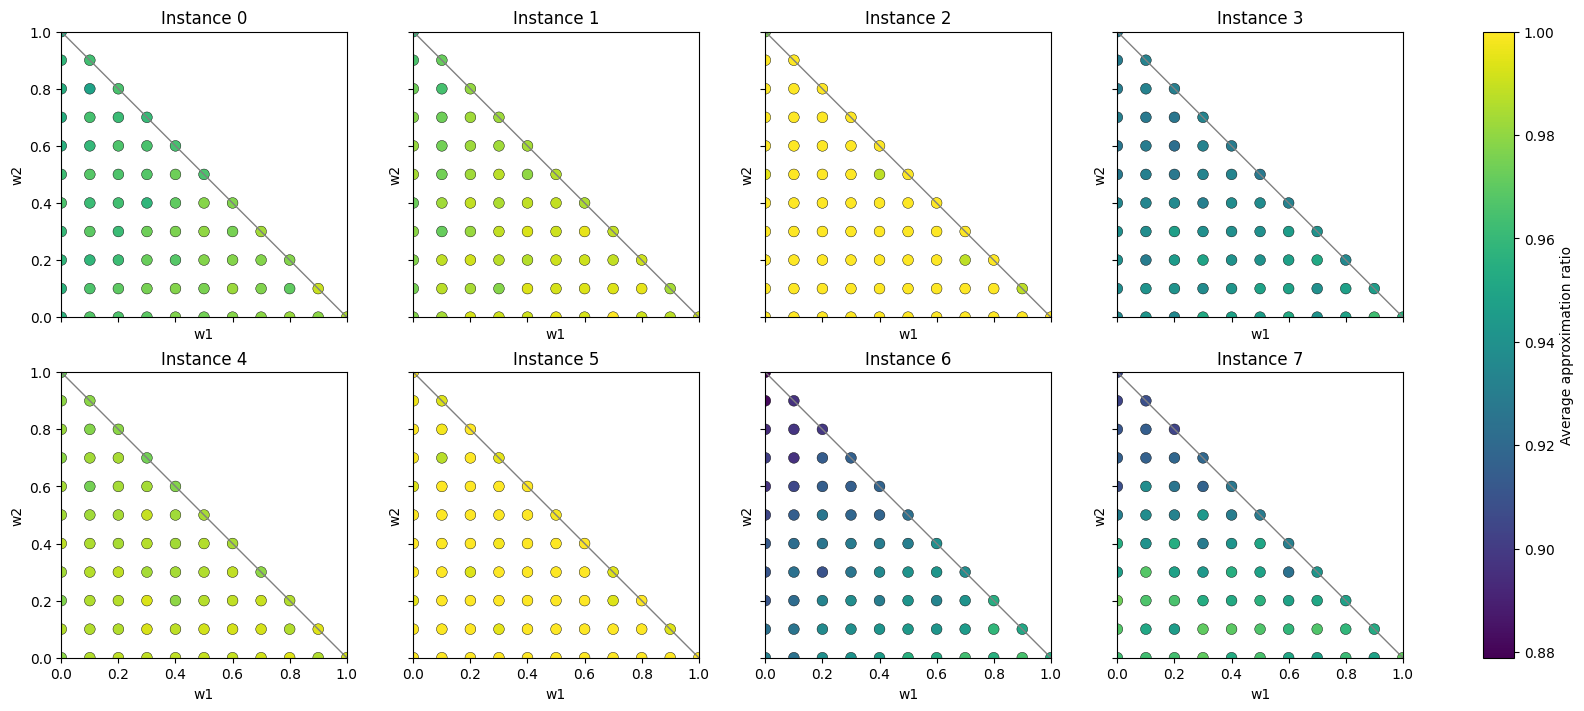

In [3]:
# Plot approximation ratio over weight simplex for each instance
weight_keys = sorted(results.keys(), key=lambda k: json.loads(k))
weights_parsed = [tuple(json.loads(k)) for k in weight_keys]

def instance_averages(instance_idx):
    w1_vals = []
    w2_vals = []
    avg_vals = []
    for key, (w1, w2, w3) in zip(weight_keys, weights_parsed):
        runs = results[key][str(instance_idx)]
        approx_values = [run_data["approx"] for run_data in runs.values()]
        w1_vals.append(w1)
        w2_vals.append(w2)
        avg_vals.append(float(np.mean(approx_values)))
    return np.array(w1_vals), np.array(w2_vals), np.array(avg_vals)

all_avgs = []
for i in range(8):
    _, _, avg_vals = instance_averages(i)
    all_avgs.append(avg_vals)
all_avgs = np.concatenate(all_avgs)

vmin = float(np.min(all_avgs))
vmax = float(np.max(all_avgs))

fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True, sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    w1_vals, w2_vals, avg_vals = instance_averages(i)
    sc = ax.scatter(
        w1_vals,
        w2_vals,
        c=avg_vals,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        s=60,
        edgecolors="black",
        linewidths=0.3,
    )
    ax.plot([0, 1], [1, 0], color="grey", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", "box")
    ax.set_title(f"Instance {i}")
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")

fig.colorbar(sc, ax=axes, label="Average approximation ratio")
plt.show()

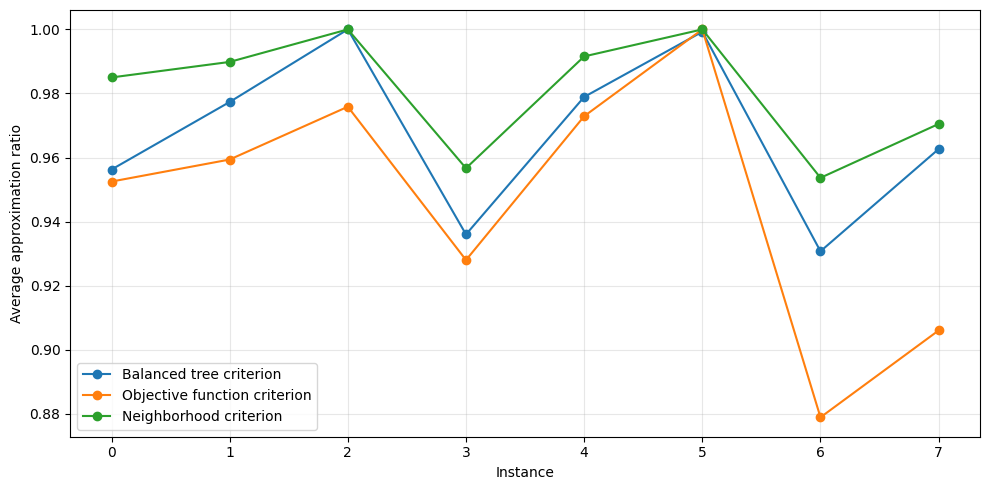

In [4]:
# Plot extreme weight criteria across instances
weight_to_key = {tuple(w): key for key, w in zip(weight_keys, weights_parsed)}

def avg_for_weight(instance_idx, weight_tuple):
    key = weight_to_key[weight_tuple]
    runs = results[key][str(instance_idx)]
    approx_values = [run_data["approx"] for run_data in runs.values()]
    return float(np.mean(approx_values))

instances_idx = np.arange(8)
balanced = [avg_for_weight(i, (0, 0, 1)) for i in instances_idx]
objective = [avg_for_weight(i, (0, 1, 0)) for i in instances_idx]
neighborhood = [avg_for_weight(i, (1, 0, 0)) for i in instances_idx]

plt.figure(figsize=(10, 5))
plt.plot(instances_idx, balanced, marker="o", label="Balanced tree criterion")
plt.plot(instances_idx, objective, marker="o", label="Objective function criterion")
plt.plot(instances_idx, neighborhood, marker="o", label="Neighborhood criterion")
plt.xlabel("Instance")
plt.ylabel("Average approximation ratio")
plt.xticks(instances_idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

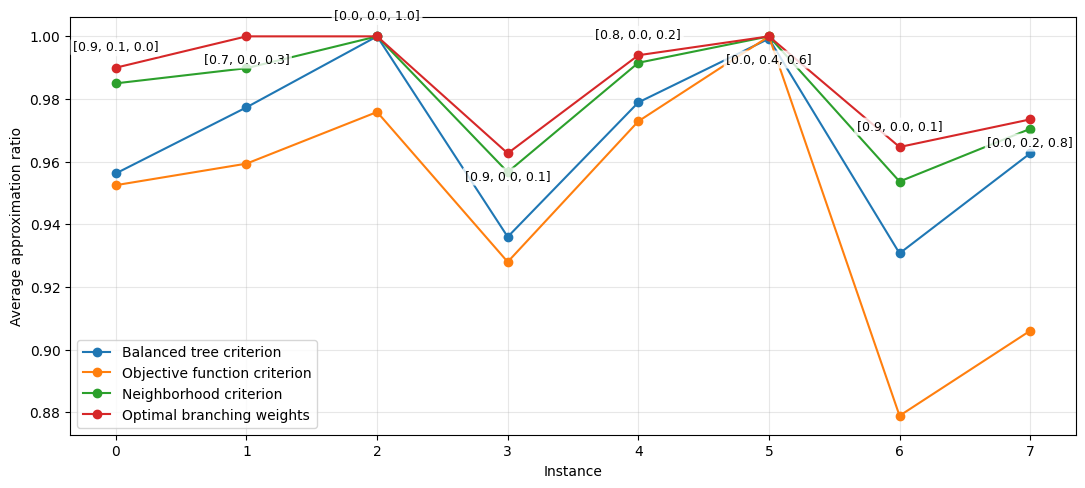

In [5]:
# Plot extreme criteria and optimal branching weights together
best_avgs = []
best_weights = []
for i in range(8):
    _, _, avg_vals = instance_averages(i)
    best_idx = int(np.argmax(avg_vals))
    best_avgs.append(float(avg_vals[best_idx]))
    best_weights.append(weights_parsed[best_idx])

instances_idx = np.arange(8)
plt.figure(figsize=(11, 5))
plt.plot(instances_idx, balanced, marker="o", label="Balanced tree criterion")
plt.plot(instances_idx, objective, marker="o", label="Objective function criterion")
plt.plot(instances_idx, neighborhood, marker="o", label="Neighborhood criterion")
plt.plot(instances_idx, best_avgs, marker="o", linestyle="-", label="Optimal branching weights")
for x, y, w in zip(instances_idx, best_avgs, best_weights):
    label = f"[{w[0]:.1f}, {w[1]:.1f}, {w[2]:.1f}]"
    y_offset = 10 if int(x) % 2 == 0 else -12
    va = "bottom" if y_offset > 0 else "top"
    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(0, y_offset),
        ha="center",
        va=va,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

plt.xlabel("Instance")
plt.ylabel("Average approximation ratio")
plt.xticks(instances_idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Plots/grover_branching_weights_comparison.pdf")
plt.show()

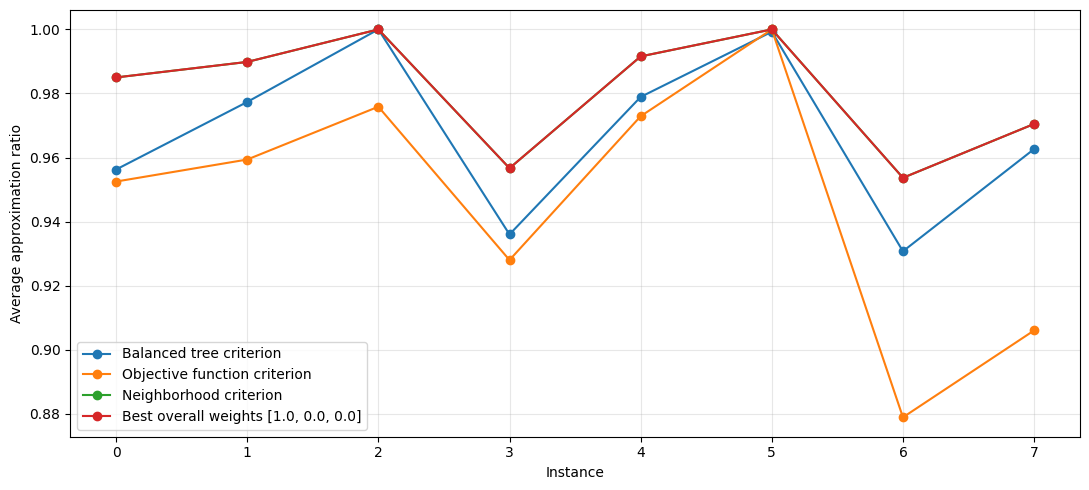

In [6]:
# Plot extreme criteria and best overall weights across instances
instances_idx = np.arange(8)
overall_avg_by_weight = []
for weight in weights_parsed:
    vals = [avg_for_weight(i, weight) for i in instances_idx]
    overall_avg_by_weight.append(float(np.mean(vals)))
best_overall_idx = int(np.argmax(overall_avg_by_weight))
best_overall_weight = weights_parsed[best_overall_idx]
best_overall_avgs = [avg_for_weight(i, best_overall_weight) for i in instances_idx]

label = (
    f"Best overall weights [{best_overall_weight[0]:.1f}, "
    f"{best_overall_weight[1]:.1f}, {best_overall_weight[2]:.1f}]"
 )

plt.figure(figsize=(11, 5))
plt.plot(instances_idx, balanced, marker="o", label="Balanced tree criterion")
plt.plot(instances_idx, objective, marker="o", label="Objective function criterion")
plt.plot(instances_idx, neighborhood, marker="o", label="Neighborhood criterion")
plt.plot(instances_idx, best_overall_avgs, marker="o", linestyle="-", label=label)

plt.xlabel("Instance")
plt.ylabel("Average approximation ratio")
plt.xticks(instances_idx)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Plots/grover_branching_weights_overall_best.pdf")
plt.show()